# 03. JEPX 東京エリア価格 - 目的変数バリアントの分析

目的: **「raw 価格を直接予測する」のが本当に最適か？** を検証する。

EPF (Electricity Price Forecasting) 文献では、ターゲット変換 (log, arsinh, デトレンド) が定石。  
JEPX は
- ピーク 100 円超のテール
- 谷 0 円付近の PV 過剰スパイク
- 経年の水準シフト (2022 LNG 危機、PV 容量増)

を抱えており、生価格 + MSE 損失だと train/test の分布シフトに弱い。  
01 で計算済みの `target_*` 各種変換を比較し、**02 のメインモデルに採用すべき形** を決める。

## 構成
1. データロード
2. **分布シフト分析** — train / val / test での `target` 分布、Q-Q プロット、時系列トレンド
3. **各変換ターゲットの分布** — log1p / arsinh / diff / dev でどれくらいテールが圧縮されるか
4. **モデル比較** — quantile p50 LightGBM を各 target で学習し、test MAE と価格帯別 MAE を比較
5. **逆変換ロジック** — predicted → raw 価格への戻し方を確認
6. **結論** — 02 に逆輸入する推奨ターゲットを決定


## ライブラリ


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401
import seaborn as sns
import scipy.stats as stats

from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb

from IPython.display import display

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid", font="IPAexGothic")


## データロード


In [2]:
BASE_DIR_CANDIDATES = [
    Path.cwd(),
    Path.cwd() / "blog" / "06.JEPX_estimation",
    Path("/home/kohei/WorkSpace/blog/06.JEPX_estimation"),
]
BASE_DIR = next((p for p in BASE_DIR_CANDIDATES if (p / "data" / "jepx_tokyo_features.parquet").exists()), None)
if BASE_DIR is None:
    raise FileNotFoundError("data/jepx_tokyo_features.parquet が見つかりません。01 を先に実行してください。")
DATA_DIR = BASE_DIR / "data"

feature_df = pd.read_parquet(DATA_DIR / "jepx_tokyo_features.parquet")
meta = json.loads((DATA_DIR / "feature_metadata.json").read_text(encoding="utf-8"))

cal_cols     = meta["calendar_cols"]
weather_cols = meta["weather_cols"]
tepco_cols   = meta["tepco_cols"]
lag_cols     = meta["lag_cols"]
target_alt_cols = meta["target_alt_cols"]
trend_cols   = meta["trend_cols"]
LOG1P_OFFSET = meta["log1p_offset"]

feature_cols = cal_cols + weather_cols + tepco_cols + lag_cols

print("shape       :", feature_df.shape)
print("period      :", feature_df.index.min(), "->", feature_df.index.max())
print("target alts :", target_alt_cols)
print("LOG1P_OFFSET:", LOG1P_OFFSET)
display(feature_df[["target"] + target_alt_cols + trend_cols].head(3))


shape       : (107472, 38)
period      : 2020-04-08 00:00:00 -> 2026-05-25 23:30:00
target alts : ['target_log1p', 'target_arsinh', 'target_diff_1d', 'target_diff_7d', 'target_dev_prev_day', 'target_dev_prev_week']
LOG1P_OFFSET: 1.0


,target,target_log1p,target_arsinh,target_diff_1d,target_diff_7d,target_dev_prev_day,target_dev_prev_week,trend_30d_mean
datetime,,,,,,,,
2020-04-08 00:00:00,6.66,2.158715,2.594856,0.21,-0.10,-0.64625,-1.927292,7.06997
2020-04-08 00:30:00,6.61,2.152924,2.587404,0.16,-0.01,-0.69625,-1.977292,7.06997
2020-04-08 01:00:00,6.54,2.144761,2.576879,0.08,-0.07,-0.76625,-2.047292,7.06997


In [3]:
# 02 と同じ時系列 hold-out
TEST_MONTHS, VAL_MONTHS = 6, 3
last_ts = feature_df.index.max()
test_start = (last_ts - pd.DateOffset(months=TEST_MONTHS)).normalize()
val_start  = (test_start - pd.DateOffset(months=VAL_MONTHS)).normalize()
train_df = feature_df.loc[: val_start - pd.Timedelta("30min")]
val_df   = feature_df.loc[val_start: test_start - pd.Timedelta("30min")]
test_df  = feature_df.loc[test_start:]

display(pd.DataFrame({
    "rows":  [len(train_df), len(val_df), len(test_df)],
    "start": [train_df.index.min(), val_df.index.min(), test_df.index.min()],
    "end":   [train_df.index.max(), val_df.index.max(), test_df.index.max()],
    "target_mean": [train_df["target"].mean(), val_df["target"].mean(), test_df["target"].mean()],
    "target_std":  [train_df["target"].std(),  val_df["target"].std(),  test_df["target"].std()],
}, index=["train", "val", "test"]).round(2))


/tmp/ipykernel_34367/2505179529.py:16: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  }, index=["train", "val", "test"]).round(2))


,rows,start,end,target_mean,target_std
train,94320,2020-04-08,2025-08-24 23:30:00,14.96,14.06
val,4416,2025-08-25,2025-11-24 23:30:00,12.79,3.48
test,8736,2025-11-25,2026-05-25 23:30:00,14.13,6.53


## 1. 分布シフト分析

train / val / test の `target` 分布がどれくらいズレているか可視化する。  
ズレが大きいなら **デトレンド系の変換 (target_dev_*) が効く** と仮説立て可能。


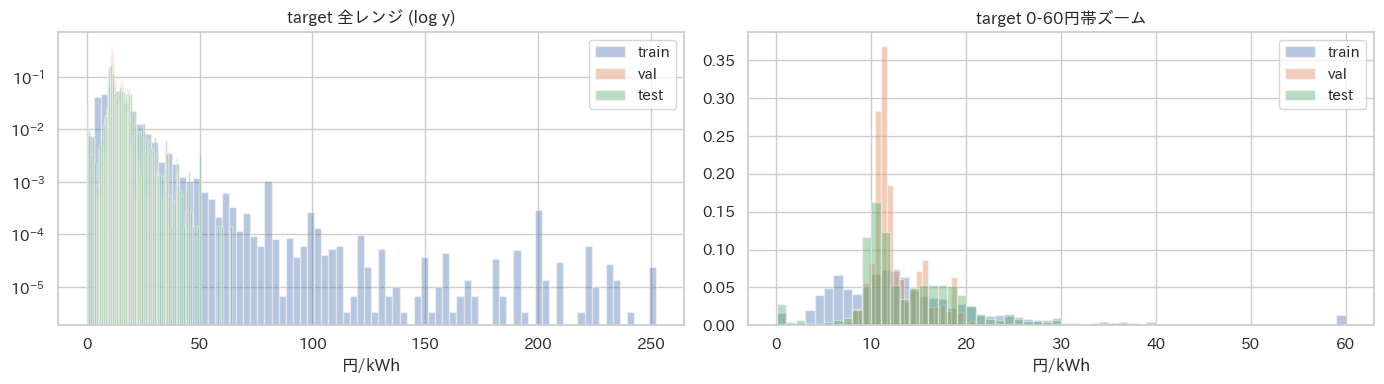

In [4]:
# ヒストグラム重ね描き (log y)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for name, df_, c in [("train", train_df, "C0"), ("val", val_df, "C1"), ("test", test_df, "C2")]:
    axes[0].hist(df_["target"], bins=80, alpha=0.4, label=name, color=c, density=True)
    axes[1].hist(df_["target"].clip(0, 60), bins=60, alpha=0.4, label=name, color=c, density=True)
axes[0].set_yscale("log"); axes[0].set_title("target 全レンジ (log y)"); axes[0].legend()
axes[1].set_title("target 0-60円帯ズーム"); axes[1].legend()
for ax in axes: ax.set_xlabel("円/kWh")
plt.tight_layout(); plt.show()


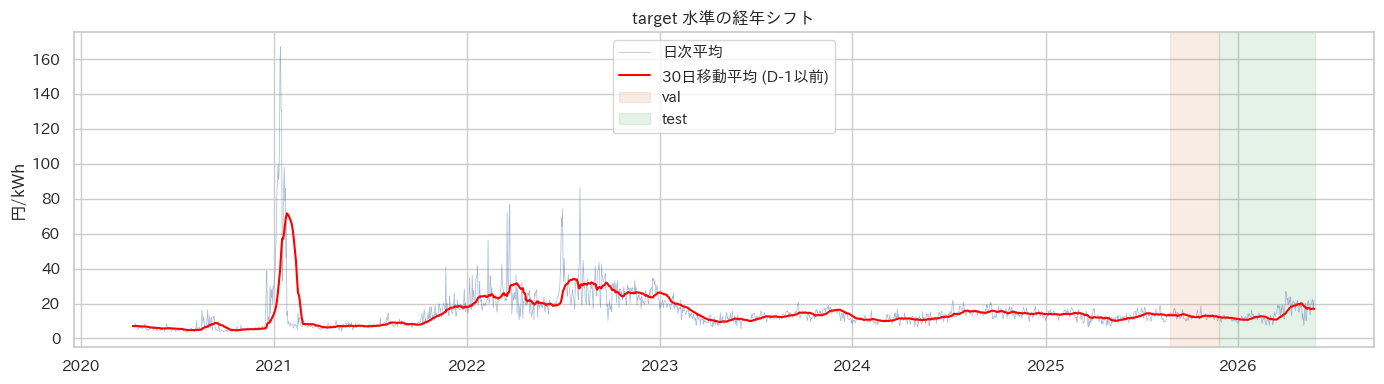

period mean / std (raw):
  train   mean=  14.96  std=  14.06  min=   0.01  max= 252.00
  val     mean=  12.79  std=   3.48  min=   3.00  max=  40.01
  test    mean=  14.13  std=   6.53  min=   0.01  max=  64.28


In [5]:
# 時系列での水準シフト: 日次平均 + 30日トレンド
daily = feature_df["target"].resample("D").mean()
trend = feature_df["trend_30d_mean"].resample("D").first()  # 各日固定値なので first で OK

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily.index, daily.values, lw=0.5, alpha=0.5, label="日次平均")
ax.plot(trend.index, trend.values, lw=1.5, color="red", label="30日移動平均 (D-1以前)")
ax.axvspan(val_df.index.min(), val_df.index.max(), color="C1", alpha=0.15, label="val")
ax.axvspan(test_df.index.min(), test_df.index.max(), color="C2", alpha=0.15, label="test")
ax.set_title("target 水準の経年シフト")
ax.set_ylabel("円/kWh")
ax.legend()
plt.tight_layout(); plt.show()

print("period mean / std (raw):")
for name, df_ in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"  {name:6s}  mean={df_['target'].mean():7.2f}  std={df_['target'].std():7.2f}  min={df_['target'].min():7.2f}  max={df_['target'].max():7.2f}")


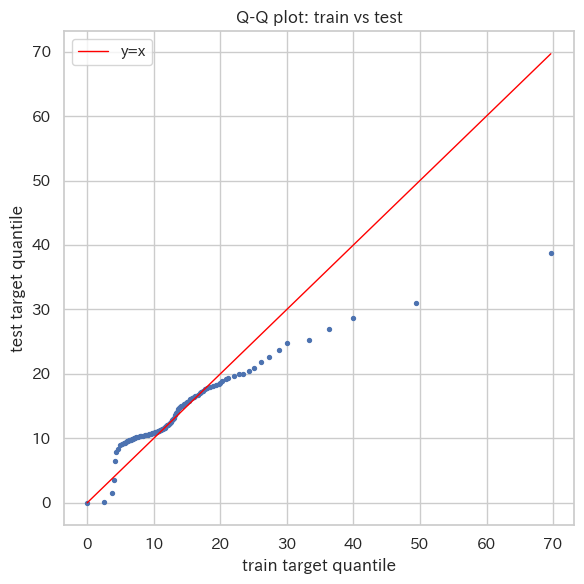

In [6]:
# Q-Q プロット: test vs train
fig, ax = plt.subplots(figsize=(6, 6))
qs = np.linspace(0.01, 0.99, 99)
ax.scatter(np.quantile(train_df["target"], qs), np.quantile(test_df["target"], qs), s=8)
lo, hi = 0, max(train_df["target"].quantile(0.99), test_df["target"].quantile(0.99))
ax.plot([lo, hi], [lo, hi], color="red", lw=1, label="y=x")
ax.set_xlabel("train target quantile")
ax.set_ylabel("test target quantile")
ax.set_title("Q-Q plot: train vs test")
ax.legend(); plt.tight_layout(); plt.show()


## 2. 各変換ターゲットの分布

log1p / arsinh / diff / dev を可視化してテール圧縮の効きを見る。


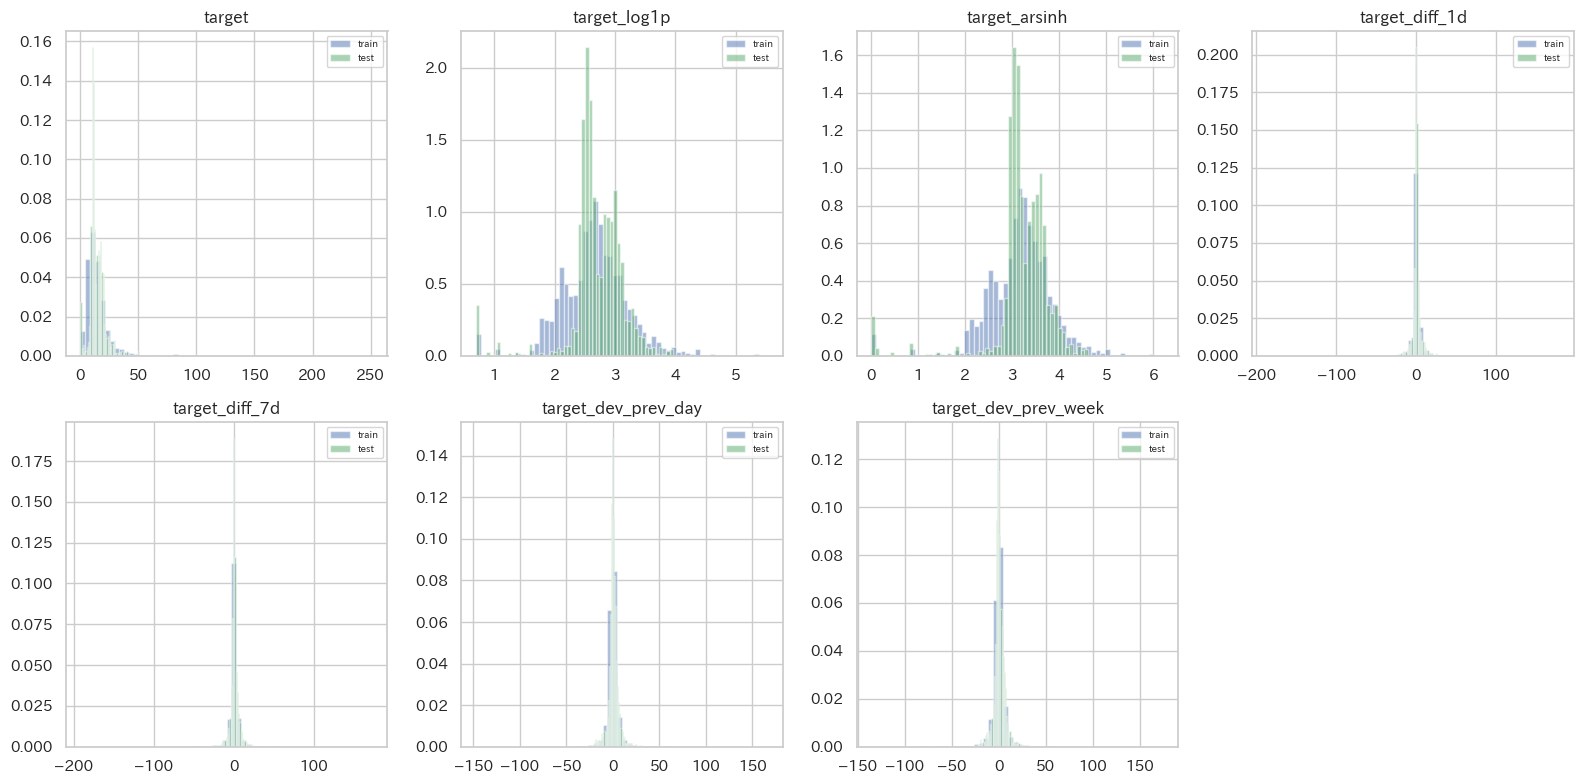

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for ax, col in zip(axes, ["target"] + target_alt_cols):
    for name, df_, c in [("train", train_df, "C0"), ("test", test_df, "C2")]:
        ax.hist(df_[col].dropna(), bins=60, alpha=0.5, label=name, color=c, density=True)
    ax.set_title(col)
    ax.legend(fontsize=7)
if len(axes) > len(["target"] + target_alt_cols):
    for ax in axes[len(["target"] + target_alt_cols):]:
        ax.set_visible(False)
plt.tight_layout(); plt.show()


## 3. モデル比較: 各 target で q50 LightGBM を学習

**評価基準**: test 期間における raw 価格スケールでの MAE / RMSE / sMAPE。  
**手順**: 各 target で学習 → 予測 → **必ず raw スケールへ逆変換してから評価**。


In [8]:
# 各 target の逆変換関数。pred は予測値、ref は逆変換に必要な参照値 (lag や prev_mean)。
INVERSE_TRANSFORMS = {
    "target":               lambda pred, df: pred,
    "target_log1p":         lambda pred, df: np.expm1(pred) - LOG1P_OFFSET,
    "target_arsinh":        lambda pred, df: np.sinh(pred),
    "target_diff_1d":       lambda pred, df: pred + df["lag_1d_same_slot"].values,
    "target_diff_7d":       lambda pred, df: pred + df["lag_7d_same_slot"].values,
    "target_dev_prev_day":  lambda pred, df: pred + df["prev_day_mean"].values,
    "target_dev_prev_week": lambda pred, df: pred + df["prev_week_same_dow_mean"].values,
}


def smape(y, p, eps=1e-3):
    y, p = np.asarray(y, float), np.asarray(p, float)
    return float(np.mean(200.0 * np.abs(p - y) / (np.abs(y) + np.abs(p) + eps)))


def eval_raw(y_raw, y_pred_raw):
    return {
        "rmse": float(np.sqrt(mean_squared_error(y_raw, y_pred_raw))),
        "mae":  float(mean_absolute_error(y_raw, y_pred_raw)),
        "smape": smape(y_raw, y_pred_raw),
    }


In [9]:
LGBM_PARAMS_Q50 = {
    "objective": "quantile", "alpha": 0.5, "metric": "quantile",
    "learning_rate": 0.02, "num_leaves": 63, "max_depth": -1,
    "min_data_in_leaf": 200, "feature_fraction": 0.8, "bagging_fraction": 0.8,
    "bagging_freq": 5, "lambda_l2": 1.0, "verbose": -1, "seed": 42,
}
N_ESTIMATORS = 5000

X_train, X_val, X_test = train_df[feature_cols], val_df[feature_cols], test_df[feature_cols]
y_test_raw = test_df["target"].values

results = []
predictions_raw = {}

for target_col in ["target"] + target_alt_cols:
    y_tr = train_df[target_col]
    y_va = val_df[target_col]
    if y_tr.isna().any() or y_va.isna().any():
        print(f"[skip] {target_col}: NaN in train/val")
        continue

    tr = lgb.Dataset(X_train, y_tr, feature_name=feature_cols)
    vd = lgb.Dataset(X_val,   y_va, feature_name=feature_cols, reference=tr)
    model = lgb.train(
        LGBM_PARAMS_Q50, tr, num_boost_round=N_ESTIMATORS,
        valid_sets=[tr, vd], valid_names=["train", "val"],
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)],
    )

    pred_transformed = model.predict(X_test, num_iteration=model.best_iteration)
    pred_raw = INVERSE_TRANSFORMS[target_col](pred_transformed, test_df)

    m = eval_raw(y_test_raw, pred_raw)
    m["target"] = target_col
    m["best_iter"] = model.best_iteration
    results.append(m)
    predictions_raw[target_col] = pred_raw
    print(f"[{target_col:24s}]  RMSE={m['rmse']:.3f}  MAE={m['mae']:.3f}  sMAPE={m['smape']:.2f}  best_iter={m['best_iter']}")

results_df = pd.DataFrame(results).set_index("target").sort_values("mae")
print("\n=== test set (MAE 昇順) ===")
display(results_df.round(3))


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[226]	train's quantile: 1.08131	val's quantile: 0.579946
[target                  ]  RMSE=3.905  MAE=2.237  sMAPE=19.30  best_iter=226
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[240]	train's quantile: 0.0573063	val's quantile: 0.0372217
[target_log1p            ]  RMSE=3.954  MAE=2.258  sMAPE=19.94  best_iter=240
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[243]	train's quantile: 0.0716261	val's quantile: 0.0426769
[target_arsinh           ]  RMSE=3.939  MAE=2.244  sMAPE=19.79  best_iter=243
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[958]	train's quantile: 0.836561	val's quantile: 0.575003
[target_diff_1d          ]  RMSE=3.955  MAE=2.279  sMAPE=20.11  best_iter=958
Training until validation scores don't improve for 100 rounds
Ear

,rmse,mae,smape,best_iter
target,,,,
target_dev_prev_day,3.850,2.230,20.013,815
target,3.905,2.237,19.303,226
target_diff_7d,3.917,2.242,19.492,446
target_arsinh,3.939,2.244,19.793,243
target_log1p,3.954,2.258,19.944,240
target_diff_1d,3.955,2.279,20.109,958
target_dev_prev_week,3.969,2.341,20.602,599


In [10]:
# 価格帯別 MAE
yt = y_test_raw
bands = [("谷 (<5)", yt < 5), ("中 (5-50)", (yt >= 5) & (yt <= 50)), ("山 (>50)", yt > 50)]
band_rows = []
for target_col, pred in predictions_raw.items():
    row = {"target": target_col}
    for name, mask in bands:
        if mask.sum() > 0:
            row[f"{name} MAE"] = float(np.mean(np.abs(yt[mask] - pred[mask])))
            row[f"{name} n"]  = int(mask.sum())
    band_rows.append(row)
band_df = pd.DataFrame(band_rows).set_index("target")
print("=== 価格帯別 MAE (test, raw スケール) ===")
display(band_df.round(3))


=== 価格帯別 MAE (test, raw スケール) ===


,谷 (<5) MAE,谷 (<5) n,中 (5-50) MAE,中 (5-50) n,山 (>50) MAE,山 (>50) n
target,,,,,,
target,4.173,368,2.125,8360,31.052,8
target_log1p,3.132,368,2.192,8360,31.211,8
target_arsinh,2.735,368,2.195,8360,31.143,8
target_diff_1d,2.868,368,2.226,8360,30.450,8
target_diff_7d,3.886,368,2.142,8360,30.884,8
target_dev_prev_day,2.769,368,2.178,8360,31.506,8
target_dev_prev_week,2.984,368,2.285,8360,30.955,8


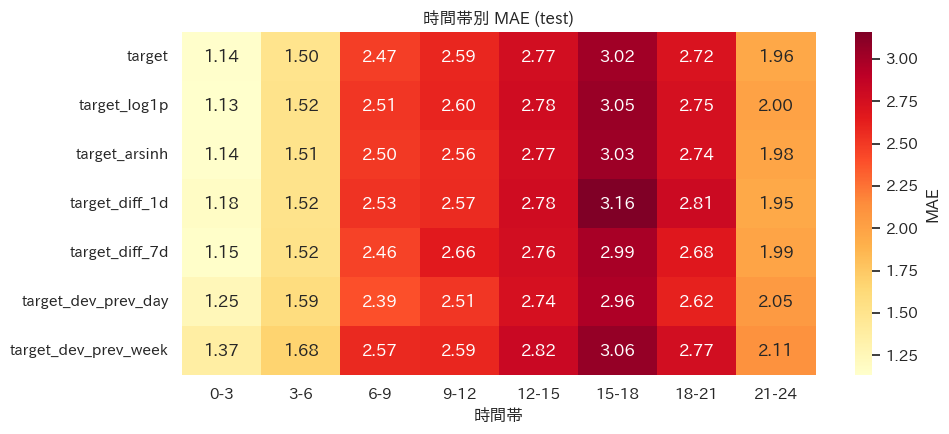

In [11]:
# 時間帯別 MAE のヒートマップ
hour = test_df.index.hour
band_idx = pd.cut(hour, bins=[-0.5, 3, 6, 9, 12, 15, 18, 21, 23.5],
                  labels=["0-3", "3-6", "6-9", "9-12", "12-15", "15-18", "18-21", "21-24"])

hour_mae = {}
for target_col, pred in predictions_raw.items():
    err = pd.Series(np.abs(yt - pred), index=test_df.index)
    hour_mae[target_col] = err.groupby(band_idx, observed=False).mean()
hour_df = pd.DataFrame(hour_mae)

fig, ax = plt.subplots(figsize=(10, len(hour_df.columns) * 0.5 + 1))
sns.heatmap(hour_df.T, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax, cbar_kws={"label": "MAE"})
ax.set_title("時間帯別 MAE (test)")
ax.set_xlabel("時間帯")
plt.tight_layout(); plt.show()


## 4. 結論と 02 への逆輸入

上記の `results_df` / `band_df` / `hour_df` を見て:

- 全体 MAE が最良のターゲット → **02 のメインモデル** に採用
- 谷帯特化が必要なら → アンサンブルの片翼として `target_log1p` などを残す
- 時間帯ごとに勝ちターゲットが分かれるなら → 時間帯別モデル (specialist) の伏線になる

実装方針が固まったら 02 の `LGBM_PARAMS` 周辺と保存セルを更新する。
